# Predicting Destiny 2 Steam Player Engagement

## Research question
**Which factors are most important in predicting next-month Destiny 2 Steam player engagement?**

This project is an end-to-end **regression** machine-learning project. Each observation represents one calendar month. The target variable is `next_month_avg_players`, the average number of concurrent Destiny 2 players on Steam in the following month.

The project combines prior player engagement, Steam review activity and sentiment, official Steam news activity, expansion timing, seasonality, and optionally Google Trends search interest.

Recently, Bungie and Sony have been having a very big problem involving the Destiny 2 IP, their newly laid off employees, and outraged fans. What I want to address is what factors contribute mostly to Destiny 2's seasonal success, this means that our target variable will be "next_month_avg_players" and that our problem will include a regression model. The people benefiting from this study range from the people that develop the game and push out updates to the fans enjoying the game. Really it is a cycle because the better the studio the more the fans will pay for the game. Bungie is one of the many studios that updates their games to the fans' reviews, and if other studios can implement this data to their games then perhaps more games will be more enjoyable. 


### Why this matters
Live-service games depend on sustained engagement. Forecasting future engagement can help researchers understand whether prior engagement, community response, public interest, communication activity, or major content releases are useful predictors of future player activity. The goal here is **prediction and interpretation**, not causal proof.


## 1. Problem Definition

- **Prediction problem:** Predict next month's average Destiny 2 Steam concurrent-player count.
- **Target:** `next_month_avg_players`
- **Task type:** Regression
- **Unit of analysis:** One calendar month
- **Potential users:** Game-industry analysts, live-service teams, researchers, and players interested in engagement trends.
- **Important scope restriction:** The outcome measures **Steam engagement only**. It does not directly measure PlayStation or Xbox engagement, revenue, retention, or monthly active users.

## 2. Background and Context

Destiny 2 is an MMORPG(Massively Multiplayer Online Role Playing Game) that progressively gets updates every month and major updates every year. Sony is the entertainment company that owns Bungie, and Bungie is the studio that created and maintains Destiny 2.

AI Provided Context:
Prior research supports treating game engagement and community response as measurable phenomena. Hamari and Keronen (2017) synthesize research on motivations for game use. Zhu and Zhang (2010) find that online consumer reviews can influence video-game sales, while Kraemer, Weiger, and Heidenreich (2025) report nonlinear relationships between review valence and video-game sales. These studies do not establish that Steam review sentiment causes Destiny 2 player activity, but they support examining reviews and engagement-related indicators as predictive features.

This project also uses official Steam APIs for reviews and news, Steam Charts for monthly concurrent-player history, and official Bungie release dates for major expansions.

## 3. Data Description

The code below creates creates the project data.

**Sources**
- Steam Charts: monthly average and peak concurrent Steam players.
- Steam `IUserReviewsService`: monthly review volume plus a capped English-language text sample for sentiment/playtime features.
- Steam `ISteamNews`: official Steam news posts associated with Destiny 2.
- Bungie official pages: expansion release dates.
- Google Trends: optional CSV export for the search term “Destiny 2.”

The review-text sample is intentionally capped for reproducibility and API load. Monthly review volume is taken from the API's query metadata rather than the capped sample size.

In [1]:
from __future__ import annotations

import json
import math
import time
from io import StringIO
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests

from sklearn.base import clone
from sklearn.compose import TransformedTargetRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer



# 0. CONFIGURATION

RANDOM_STATE = 42
APP_ID = 1085660

STEAM_CHARTS_URL = f"https://steamcharts.com/app/{APP_ID}"
STEAM_REVIEWS_URL = (
    "https://api.steampowered.com/"
    "IUserReviewsService/GetAppReviews/v1/"
)
STEAM_NEWS_URL = (
    "https://api.steampowered.com/"
    "ISteamNews/GetNewsForApp/v2/"
)

PROJECT_DIR = Path(".")
DATA_RAW = PROJECT_DIR / "data" / "raw"
DATA_PROCESSED = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "figures"
RESULTS_DIR = PROJECT_DIR / "results"
MODELS_DIR = PROJECT_DIR / "models"

for folder in [
    DATA_RAW,
    DATA_PROCESSED,
    FIGURES_DIR,
    RESULTS_DIR,
    MODELS_DIR,
]:
    folder.mkdir(parents=True, exist_ok=True)

# Review-text sampling controls.
# The API's total_matching field is used for monthly review volume,
# while a capped sample of review text is used for sentiment/playtime.
MAX_REVIEW_TEXT_SAMPLE_PER_MONTH = 300
REQUEST_PAUSE_SECONDS = 0.15
REQUEST_TIMEOUT = 30

# If this file does not exist, the project still runs without Trends.
GOOGLE_TRENDS_FILE = DATA_RAW / "google_trends.csv"




In [2]:
# 1. HELPER FUNCTIONS by AI


def save_figure(filename: str) -> None:
    """Save the current matplotlib figure to the figures folder."""
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / filename, dpi=200, bbox_inches="tight")


def safe_request(
    url: str,
    *,
    params: dict | None = None,
    headers: dict | None = None,
    timeout: int = REQUEST_TIMEOUT,
    max_attempts: int = 5,
) -> requests.Response:
    """
    GET request with basic retry behavior for temporary API errors/rate limits.
    """
    last_error = None

    for attempt in range(max_attempts):
        try:
            response = requests.get(
                url,
                params=params,
                headers=headers,
                timeout=timeout,
            )

            if response.status_code == 429:
                time.sleep(2 ** attempt)
                continue

            response.raise_for_status()
            return response

        except requests.RequestException as exc:
            last_error = exc
            if attempt < max_attempts - 1:
                time.sleep(2 ** attempt)

    raise RuntimeError(
        f"Request failed after {max_attempts} attempts: {url}"
    ) from last_error


def regression_metrics(y_true, y_pred) -> dict:
    """Return common regression metrics."""
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": math.sqrt(mean_squared_error(y_true, y_pred)),
        "R2": r2_score(y_true, y_pred),
        "MAPE_percent": mean_absolute_percentage_error(
            y_true, y_pred
        ) * 100,
    }




In [3]:
# 2. COLLECT STEAM PLAYER DATA

def download_steamcharts() -> pd.DataFrame:
    """
    Download the Destiny 2 monthly Steam Charts table.

    Returns one row per COMPLETE calendar month.
    'Last 30 Days' is removed because it is a rolling/incomplete period.
    """
    headers = {
        "User-Agent": (
            "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
            "AppleWebKit/537.36 Chrome/120 Safari/537.36"
        )
    }

    response = safe_request(
        STEAM_CHARTS_URL,
        headers=headers,
    )

    tables = pd.read_html(StringIO(response.text))

    expected = {
        "Month",
        "Avg. Players",
        "Gain",
        "% Gain",
        "Peak Players",
    }

    player_table = None

    for table in tables:
        if expected.issubset(set(table.columns)):
            player_table = table.copy()
            break

    if player_table is None:
        raise ValueError(
            "Could not identify the Steam Charts monthly table. "
            "Inspect pd.read_html() output because the page layout may "
            "have changed."
        )

    player_table = player_table[
        player_table["Month"] != "Last 30 Days"
    ].copy()

    player_table = player_table.rename(
        columns={
            "Month": "month",
            "Avg. Players": "avg_players",
            "Gain": "player_gain",
            "% Gain": "percent_gain",
            "Peak Players": "peak_players",
        }
    )

    player_table["month"] = pd.to_datetime(
        player_table["month"],
        format="%B %Y",
        errors="coerce",
    )

    for col in [
        "avg_players",
        "player_gain",
        "peak_players",
    ]:
        player_table[col] = pd.to_numeric(
            player_table[col],
            errors="coerce",
        )

    player_table["percent_gain"] = (
        player_table["percent_gain"]
        .astype(str)
        .str.replace("%", "", regex=False)
        .str.replace("+", "", regex=False)
        .str.replace(",", "", regex=False)
        .replace({"-": np.nan, "nan": np.nan})
    )

    player_table["percent_gain"] = pd.to_numeric(
        player_table["percent_gain"],
        errors="coerce",
    )

    player_table = (
        player_table
        .dropna(subset=["month", "avg_players"])
        .sort_values("month")
        .drop_duplicates(subset=["month"])
        .reset_index(drop=True)
    )

    return player_table


steamcharts_cache = DATA_RAW / "steamcharts_monthly.csv"

if steamcharts_cache.exists():
    players = pd.read_csv(
        steamcharts_cache,
        parse_dates=["month"],
    )
else:
    players = download_steamcharts()
    players.to_csv(steamcharts_cache, index=False)

print("\nSteam player data:")
print(players.head())
print(players.tail())
print(f"Rows: {len(players)}")
print(
    "Date range:",
    players["month"].min().date(),
    "to",
    players["month"].max().date(),
)


# ============================================================


Steam player data:
       month  avg_players  player_gain  percent_gain  peak_players
0 2019-10-01    165307.82          NaN           NaN        292314
1 2019-11-01    107955.77    -57352.05        -34.69        195407
2 2019-12-01     92170.98    -15784.79        -14.62        138593
3 2020-01-01     65955.10    -26215.88        -28.44        108724
4 2020-02-01     63048.62     -2906.48         -4.41         93065
        month  avg_players  player_gain  percent_gain  peak_players
79 2026-05-01     10497.76      2627.90         33.39         28510
80 2026-06-01     67398.67     56900.90        542.03        167867
81 2026-07-01     49766.16    -17632.51        -26.16         93088
82 2026-08-01     24933.29    -24832.87        -49.90         46519
83 2026-09-01     17341.20     -7592.09        -30.45         37341
Rows: 84
Date range: 2019-10-01 to 2026-09-01


In [4]:
# 3. COLLECT AND AGGREGATE STEAM REVIEW DATA

sentiment_analyzer = SentimentIntensityAnalyzer()


def _review_api_request(payload: dict) -> dict:
    """
    Call the current Steam IUserReviewsService API.

    Steam service APIs accept request fields inside input_json.
    This helper also handles either a direct response dictionary
    or a {'response': ...} wrapper.
    """
    response = safe_request(
        STEAM_REVIEWS_URL,
        params={
            "input_json": json.dumps(payload)
        },
    )

    data = response.json()

    if "response" in data and isinstance(
        data["response"], dict
    ):
        return data["response"]

    return data


def fetch_review_sample_for_month(
    month_start: pd.Timestamp,
    max_sample: int = MAX_REVIEW_TEXT_SAMPLE_PER_MONTH,
) -> tuple[pd.DataFrame, dict]:
    """
    Fetch a capped English-language review sample for one month.

    The sample is used for text sentiment and playtime summaries.
    Steam's total_matching/query_summary fields are retained so that
    monthly review volume is not limited by the sample cap.
    """
    start = pd.Timestamp(
        month_start,
        tz="UTC",
    )

    end = (
        start
        + pd.offsets.MonthBegin(1)
        - pd.Timedelta(seconds=1)
    )

    cursor = "*"
    collected = []
    first_page_meta = {}

    while len(collected) < max_sample:
        payload = {
            "appid": APP_ID,
            "filter": 1,              # Recent
            "languages": ["english"],
            "review_type": 0,         # All
            "purchase_type": 1,       # All purchase types
            "num_per_page": min(
                100,
                max_sample - len(collected),
            ),
            "filter_offtopic_activity": True,
            "date_range_start": int(start.timestamp()),
            "date_range_end": int(end.timestamp()),
        }

        if cursor != "*":
            payload["cursor"] = cursor

        data = _review_api_request(payload)

        page_reviews = data.get("reviews", [])

        if not first_page_meta:
            first_page_meta = {
                "total_matching": data.get(
                    "total_matching",
                    np.nan,
                ),
                "query_summary": data.get(
                    "query_summary",
                    {},
                ),
            }

        if not page_reviews:
            break

        collected.extend(page_reviews)

        new_cursor = data.get("cursor")

        if (
            not new_cursor
            or new_cursor == cursor
        ):
            break

        cursor = new_cursor
        time.sleep(REQUEST_PAUSE_SECONDS)

    if not collected:
        return pd.DataFrame(), first_page_meta

    rows = []

    for review in collected[:max_sample]:
        author = review.get("author", {}) or {}

        rows.append(
            {
                "recommendationid": review.get(
                    "recommendationid"
                ),
                "review": review.get(
                    "review",
                    "",
                ),
                "timestamp_created": review.get(
                    "timestamp_created"
                ),
                "voted_up": review.get(
                    "voted_up"
                ),
                "votes_up": review.get(
                    "votes_up",
                    0,
                ),
                "weighted_vote_score": review.get(
                    "weighted_vote_score",
                    np.nan,
                ),
                "playtime_at_review_minutes": author.get(
                    "playtime_at_review",
                    np.nan,
                ),
                "playtime_forever_minutes": author.get(
                    "playtime_forever",
                    np.nan,
                ),
            }
        )

    df = pd.DataFrame(rows)

    df["review"] = df["review"].fillna("").astype(str)

    df["sentiment_compound"] = df["review"].map(
        lambda text: sentiment_analyzer
        .polarity_scores(text)["compound"]
    )

    df["playtime_at_review_hours"] = (
        pd.to_numeric(
            df["playtime_at_review_minutes"],
            errors="coerce",
        )
        / 60
    )

    return df, first_page_meta


def collect_monthly_review_features(
    months: pd.Series,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Collect monthly review features for every player-data month.

    Returns:
    - monthly aggregate feature table
    - sampled raw review rows used for sentiment
    """
    monthly_rows = []
    raw_samples = []

    unique_months = (
        pd.to_datetime(months)
        .drop_duplicates()
        .sort_values()
    )

    for month_start in unique_months:
        label = month_start.strftime("%Y-%m")
        print(f"Collecting reviews for {label}...")

        try:
            sample, meta = fetch_review_sample_for_month(
                month_start
            )

            query_summary = (
                meta.get("query_summary", {})
                if meta
                else {}
            )

            total_matching = (
                meta.get("total_matching", np.nan)
                if meta
                else np.nan
            )

            # Prefer total_matching from the date-filtered query.
            # Fall back to the sample size if unavailable.
            if pd.isna(total_matching):
                total_matching = len(sample)

            if sample.empty:
                monthly_rows.append(
                    {
                        "month": month_start,
                        "review_count": total_matching,
                        "review_sample_size": 0,
                        "positive_review_pct": np.nan,
                        "avg_review_sentiment": np.nan,
                        "avg_review_playtime_hours": np.nan,
                    }
                )
                continue

            sample["month"] = month_start
            raw_samples.append(sample)

            # If the API query summary exposes positive/negative counts,
            # use them for the monthly recommendation percentage.
            total_positive = query_summary.get(
                "total_positive",
                np.nan,
            )
            total_negative = query_summary.get(
                "total_negative",
                np.nan,
            )

            if (
                pd.notna(total_positive)
                and pd.notna(total_negative)
                and (total_positive + total_negative) > 0
            ):
                positive_pct = (
                    total_positive
                    / (total_positive + total_negative)
                    * 100
                )
            else:
                positive_pct = (
                    sample["voted_up"]
                    .astype(float)
                    .mean()
                    * 100
                )

            monthly_rows.append(
                {
                    "month": month_start,
                    "review_count": total_matching,
                    "review_sample_size": len(sample),
                    "positive_review_pct": positive_pct,
                    "avg_review_sentiment": (
                        sample["sentiment_compound"].mean()
                    ),
                    "avg_review_playtime_hours": (
                        sample[
                            "playtime_at_review_hours"
                        ].median()
                    ),
                }
            )

        except Exception as exc:
            print(
                f"WARNING: review collection failed for "
                f"{label}: {exc}"
            )

            monthly_rows.append(
                {
                    "month": month_start,
                    "review_count": np.nan,
                    "review_sample_size": 0,
                    "positive_review_pct": np.nan,
                    "avg_review_sentiment": np.nan,
                    "avg_review_playtime_hours": np.nan,
                }
            )

        time.sleep(REQUEST_PAUSE_SECONDS)

    monthly = pd.DataFrame(monthly_rows)

    if raw_samples:
        raw = pd.concat(
            raw_samples,
            ignore_index=True,
        )
    else:
        raw = pd.DataFrame()

    return monthly, raw


review_monthly_cache = DATA_RAW / "reviews_monthly.csv"
review_sample_cache = DATA_RAW / "review_text_sample.csv"

if review_monthly_cache.exists():
    monthly_reviews = pd.read_csv(
        review_monthly_cache,
        parse_dates=["month"],
    )

    if review_sample_cache.exists():
        review_sample = pd.read_csv(
            review_sample_cache
        )
    else:
        review_sample = pd.DataFrame()
else:
    monthly_reviews, review_sample = (
        collect_monthly_review_features(
            players["month"]
        )
    )

    monthly_reviews.to_csv(
        review_monthly_cache,
        index=False,
    )

    if not review_sample.empty:
        review_sample.to_csv(
            review_sample_cache,
            index=False,
        )

print("\nMonthly review features:")
print(monthly_reviews.head())
print(monthly_reviews.isna().sum())


Monthly review features:
       month  review_count  review_sample_size  positive_review_pct  \
0 2019-10-01         22721                 300            79.864443   
1 2019-11-01         38810                 300            89.925277   
2 2019-12-01         14465                 300            89.567923   
3 2020-01-01          6696                 300            87.753883   
4 2020-02-01          4667                 300            87.529462   

   avg_review_sentiment  avg_review_playtime_hours  
0              0.440583                 101.591667  
1              0.458379                  49.575000  
2              0.425786                  32.775000  
3              0.389069                  40.875000  
4              0.381834                  45.058333  
month                        0
review_count                 0
review_sample_size           0
positive_review_pct          0
avg_review_sentiment         0
avg_review_playtime_hours    0
dtype: int64


In [5]:
# 4. COLLECT STEAM NEWS / ANNOUNCEMENT DATA

def collect_steam_news(
    min_date: pd.Timestamp,
) -> pd.DataFrame:
    """
    Collect Steam news posts backward in time using the enddate parameter.
    """
    all_items = []
    enddate = None

    min_ts = int(
        pd.Timestamp(
            min_date,
            tz="UTC",
        ).timestamp()
    )

    while True:
        params = {
            "appid": APP_ID,
            "count": 100,
            "maxlength": 0,
        }

        if enddate is not None:
            params["enddate"] = enddate

        response = safe_request(
            STEAM_NEWS_URL,
            params=params,
        )

        data = response.json()
        items = (
            data
            .get("appnews", {})
            .get("newsitems", [])
        )

        if not items:
            break

        all_items.extend(items)

        dates = [
            item.get("date")
            for item in items
            if item.get("date") is not None
        ]

        if not dates:
            break

        earliest = min(dates)

        if earliest <= min_ts:
            break

        enddate = earliest - 1
        time.sleep(REQUEST_PAUSE_SECONDS)

    news = pd.DataFrame(all_items)

    if news.empty:
        return news

    news["date"] = pd.to_datetime(
        news["date"],
        unit="s",
        errors="coerce",
    )

    news = (
        news
        .dropna(subset=["date"])
        .drop_duplicates(subset=["gid"])
        .sort_values("date")
        .reset_index(drop=True)
    )

    return news


news_cache = DATA_RAW / "steam_news.csv"

if news_cache.exists():
    news = pd.read_csv(
        news_cache,
        parse_dates=["date"],
    )
else:
    news = collect_steam_news(
        players["month"].min()
    )
    news.to_csv(news_cache, index=False)

if news.empty:
    monthly_news = pd.DataFrame(
        {
            "month": players["month"],
            "announcement_count": np.nan,
        }
    )
else:
    news["month"] = (
        news["date"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    monthly_news = (
        news
        .groupby("month")
        .size()
        .rename("announcement_count")
        .reset_index()
    )

print("\nMonthly news data:")
print(monthly_news.head())


Monthly news data:
       month  announcement_count
0 2019-06-01                   7
1 2019-07-01                   8
2 2019-08-01                  14
3 2019-09-01                   6
4 2019-10-01                  99


In [6]:
# 5. CREATE CONTENT-RELEASE FEATURES

# Expansion dates are coded from official Bungie announcements/pages.
# This is intentionally a small, transparent event table rather than
# an opaque third-party dataset.
expansions = pd.DataFrame(
    [
        ("2019-10-01", "Shadowkeep"),
        ("2020-11-10", "Beyond Light"),
        ("2022-02-22", "The Witch Queen"),
        ("2023-02-28", "Lightfall"),
        ("2024-06-04", "The Final Shape"),
        ("2025-07-15", "The Edge of Fate"),
        ("2025-12-02", "Renegades"),
    ],
    columns=["release_date", "expansion_name"],
)

expansions["release_date"] = pd.to_datetime(
    expansions["release_date"]
)

expansions["month"] = (
    expansions["release_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

expansion_months = set(expansions["month"])


def add_release_features(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()

    out["expansion_release"] = (
        out["month"].isin(expansion_months).astype(int)
    )

    last_expansion_month = None
    months_since = []

    for month in out["month"]:
        eligible = expansions.loc[
            expansions["month"] <= month,
            "month",
        ]

        if eligible.empty:
            months_since.append(np.nan)
            continue

        last_expansion_month = eligible.max()

        months_since.append(
            (
                month.year - last_expansion_month.year
            ) * 12
            + (
                month.month - last_expansion_month.month
            )
        )

    out["months_since_expansion"] = months_since

    return out




### Optional Google Trends feature by AI

If you want search interest in the model, export an **Interest Over Time** CSV for **Destiny 2** from Google Trends and save it as:

`data/raw/google_trends.csv`

The project still runs if this file is absent. Google Trends values are normalized search-interest scores, not raw search counts.

In [7]:
# 6. OPTIONAL GOOGLE TRENDS DATA

def load_google_trends(
    path: Path,
) -> pd.DataFrame | None:
    """
    Load a Google Trends CSV exported for the search term 'Destiny 2'.

    Expected format:
    - first data column = Week or Month
    - second data column = Trends score

    Google sometimes includes a metadata row at the top. This function
    tries both normal parsing and skiprows=1.
    """
    if not path.exists():
        print(
            "\nNo Google Trends CSV found. "
            "Continuing without Google Trends."
        )
        return None

    candidates = []

    for skiprows in [0, 1]:
        try:
            temp = pd.read_csv(
                path,
                skiprows=skiprows,
            )
            candidates.append(temp)
        except Exception:
            pass

    trends = None

    for candidate in candidates:
        if candidate.shape[1] >= 2:
            trends = candidate.iloc[:, :2].copy()
            break

    if trends is None:
        raise ValueError(
            "Could not parse google_trends.csv."
        )

    trends.columns = [
        "date",
        "google_trends_score",
    ]

    trends["date"] = pd.to_datetime(
        trends["date"],
        errors="coerce",
    )

    trends["google_trends_score"] = (
        trends["google_trends_score"]
        .astype(str)
        .str.replace("<1", "0.5", regex=False)
    )

    trends["google_trends_score"] = pd.to_numeric(
        trends["google_trends_score"],
        errors="coerce",
    )

    trends = trends.dropna(
        subset=["date"]
    )

    trends["month"] = (
        trends["date"]
        .dt.to_period("M")
        .dt.to_timestamp()
    )

    monthly_trends = (
        trends
        .groupby("month", as_index=False)
        ["google_trends_score"]
        .mean()
    )

    return monthly_trends


monthly_trends = load_google_trends(
    GOOGLE_TRENDS_FILE
)





No Google Trends CSV found. Continuing without Google Trends.


## 4. Data Understanding and Exploration

Before modeling, the project inspects dataset size, missing values, summary statistics, target distribution, engagement over time, and feature correlations. These plots help identify extreme release-month spikes, skewed variables, missing review data, and strong correlations that may affect modeling.

In [8]:
# 7. MERGE DATASETS AND ENGINEER FEATURES

df = players.merge(
    monthly_reviews,
    on="month",
    how="left",
)

df = df.merge(
    monthly_news,
    on="month",
    how="left",
)

df = add_release_features(df)

if monthly_trends is not None:
    df = df.merge(
        monthly_trends,
        on="month",
        how="left",
    )

# A missing monthly news row means no returned news posts for that month.
df["announcement_count"] = (
    df["announcement_count"]
    .fillna(0)
)

# Log transforms reduce the influence of extremely high activity months.
df["review_count_log"] = np.log1p(
    pd.to_numeric(
        df["review_count"],
        errors="coerce",
    )
)

df["announcement_count_log"] = np.log1p(
    df["announcement_count"]
)

# Current engagement and short historical trend.
df["current_avg_players"] = df["avg_players"]

df["rolling3_avg_players"] = (
    df["avg_players"]
    .rolling(window=3, min_periods=3)
    .mean()
)

# Cyclical month-of-year encoding.
df["month_number"] = df["month"].dt.month

df["month_sin"] = np.sin(
    2 * np.pi * df["month_number"] / 12
)

df["month_cos"] = np.cos(
    2 * np.pi * df["month_number"] / 12
)

# TARGET:
# At the end of month t, predict average Steam players in month t+1.
df["next_month_avg_players"] = (
    df["avg_players"]
    .shift(-1)
)

df["target_month"] = (
    df["month"]
    + pd.offsets.MonthBegin(1)
)

# Drop the newest row because next month's final average is not known.
model_df = df.dropna(
    subset=["next_month_avg_players"]
).copy()

model_df.to_csv(
    DATA_PROCESSED / "destiny2_monthly_model_data.csv",
    index=False,
)

print("\nCombined model dataset:")
print(model_df.head())
print("\nDataset shape:", model_df.shape)
print("\nMissing values:")
print(
    model_df.isna()
    .sum()
    .sort_values(ascending=False)
)


Combined model dataset:
       month  avg_players  player_gain  percent_gain  peak_players  \
0 2019-10-01    165307.82          NaN           NaN        292314   
1 2019-11-01    107955.77    -57352.05        -34.69        195407   
2 2019-12-01     92170.98    -15784.79        -14.62        138593   
3 2020-01-01     65955.10    -26215.88        -28.44        108724   
4 2020-02-01     63048.62     -2906.48         -4.41         93065   

   review_count  review_sample_size  positive_review_pct  \
0         22721                 300            79.864443   
1         38810                 300            89.925277   
2         14465                 300            89.567923   
3          6696                 300            87.753883   
4          4667                 300            87.529462   

   avg_review_sentiment  avg_review_playtime_hours  ...  \
0              0.440583                 101.591667  ...   
1              0.458379                  49.575000  ...   
2              0


Summary statistics:
                          count                           mean  \
month                        83  2023-03-02 08:05:46.987951872   
avg_players                83.0                   54491.810602   
player_gain                82.0                   -1711.884268   
percent_gain               82.0                        8.57061   
peak_players               83.0                  113237.373494   
review_count               83.0                    4684.843373   
review_sample_size         83.0                          300.0   
positive_review_pct        83.0                      74.658266   
avg_review_sentiment       83.0                        0.26211   
avg_review_playtime_hours  83.0                     132.882229   
announcement_count         83.0                      17.301205   
expansion_release          83.0                       0.084337   
months_since_expansion     83.0                       5.939759   
review_count_log           83.0                       8

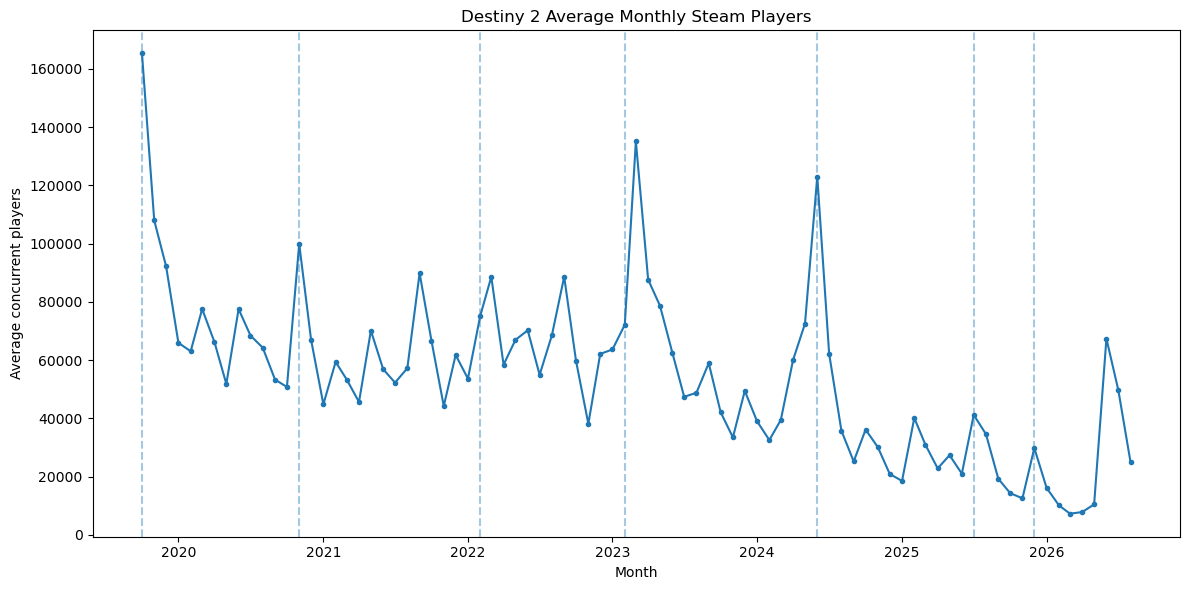

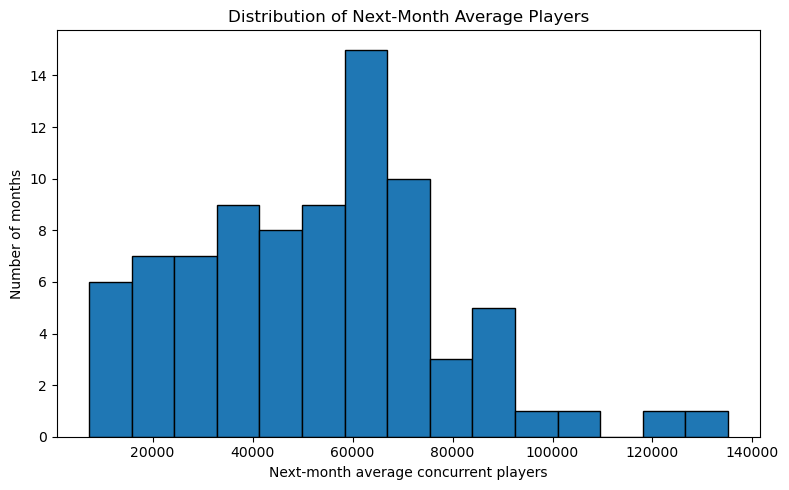

In [9]:
# 8. DATA UNDERSTANDING / EXPLORATORY ANALYSIS

print("\nSummary statistics:")
print(
    model_df.describe(
        include="all"
    ).transpose()
)

# 8A. Engagement over time
plt.figure(figsize=(12, 6))
plt.plot(
    model_df["month"],
    model_df["avg_players"],
    marker="o",
    markersize=3,
)
plt.title(
    "Destiny 2 Average Monthly Steam Players"
)
plt.xlabel("Month")
plt.ylabel("Average concurrent players")

for _, row in expansions.iterrows():
    release_month = row["month"]

    if (
        model_df["month"].min()
        <= release_month
        <= model_df["month"].max()
    ):
        plt.axvline(
            release_month,
            linestyle="--",
            alpha=0.4,
        )

save_figure(
    "01_monthly_players_over_time.png"
)
plt.show()


# 8B. Target distribution
plt.figure(figsize=(8, 5))
plt.hist(
    model_df["next_month_avg_players"],
    bins=15,
    edgecolor="black",
)
plt.title(
    "Distribution of Next-Month Average Players"
)
plt.xlabel("Next-month average concurrent players")
plt.ylabel("Number of months")
save_figure(
    "02_target_distribution.png"
)
plt.show()

## 5. Data Preparation and Feature Selection

The model uses:
- current monthly average players,
- a 3-month rolling player average,
- log-transformed review volume,
- positive review percentage,
- average VADER review sentiment,
- median playtime at review,
- log-transformed announcement count,
- expansion-release indicator,
- months since the most recent expansion,
- cyclical month-of-year features,
- optional Google Trends score.

The target is shifted one month forward so month *t* predicts month *t+1*. Missing predictors are imputed **inside the modeling pipeline**, which prevents the holdout period from influencing training-time imputation. The project does not use next-month information as a feature.


Selected features:
- current_avg_players
- rolling3_avg_players
- review_count_log
- positive_review_pct
- avg_review_sentiment
- avg_review_playtime_hours
- announcement_count_log
- expansion_release
- months_since_expansion
- month_sin
- month_cos


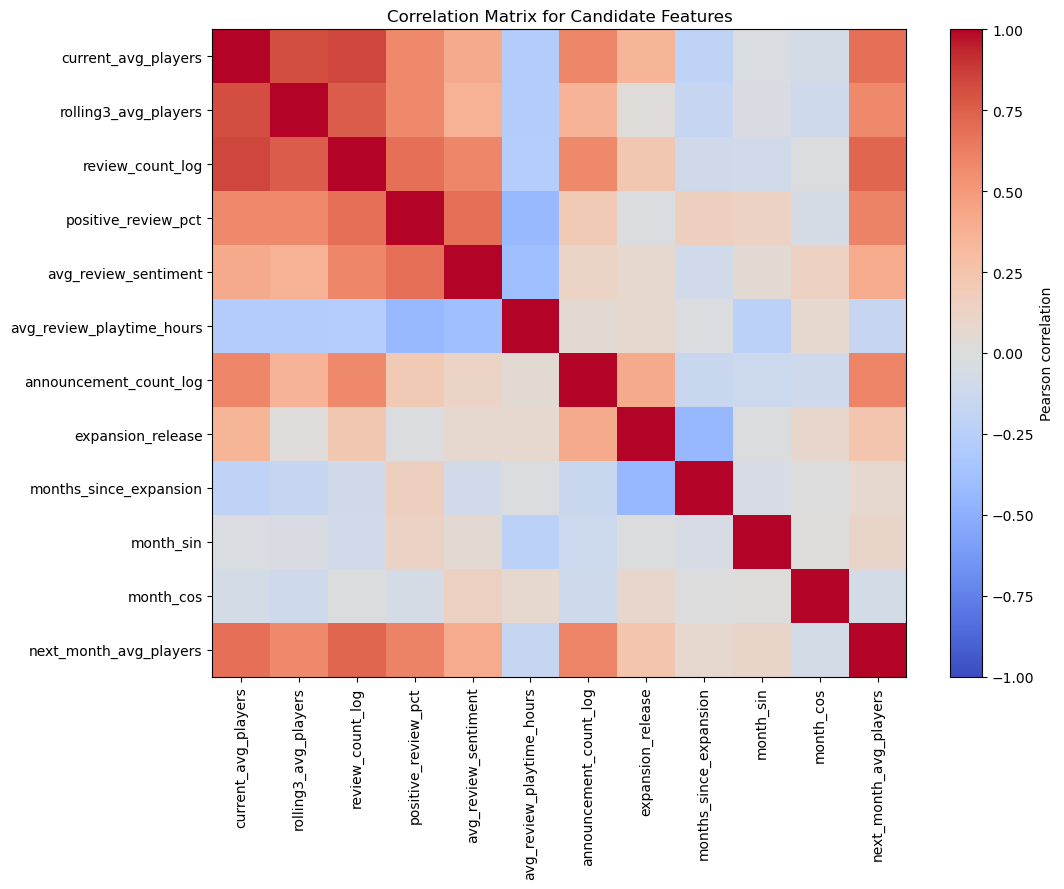

In [10]:
# 9. FEATURE SELECTION

features = [
    "current_avg_players",
    "rolling3_avg_players",
    "review_count_log",
    "positive_review_pct",
    "avg_review_sentiment",
    "avg_review_playtime_hours",
    "announcement_count_log",
    "expansion_release",
    "months_since_expansion",
    "month_sin",
    "month_cos",
]

if (
    "google_trends_score" in model_df.columns
    and model_df[
        "google_trends_score"
    ].notna().any()
):
    features.append(
        "google_trends_score"
    )

target = "next_month_avg_players"

print("\nSelected features:")
for feature in features:
    print("-", feature)

# Correlation matrix is descriptive only.
corr_cols = features + [target]

corr = (
    model_df[corr_cols]
    .corr(numeric_only=True)
)

plt.figure(figsize=(11, 9))
image = plt.imshow(
    corr,
    aspect="auto",
    vmin=-1,
    vmax=1,
    cmap="coolwarm",
)

plt.colorbar(
    image,
    label="Pearson correlation",
)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=90,
)

plt.yticks(
    range(len(corr.index)),
    corr.index,
)

plt.title(
    "Correlation Matrix for Candidate Features"
)

save_figure(
    "03_correlation_matrix.png"
)
plt.show()

In [11]:
# 10. CHRONOLOGICAL TRAIN / TEST SPLIT

# Use the most recent ~20% of months as a true future holdout.
# Keep at least 12 months in the holdout when possible.
test_size = max(
    12,
    round(len(model_df) * 0.20),
)

# Avoid allowing the test set to consume too much of a small dataset.
test_size = min(
    test_size,
    max(1, len(model_df) // 3),
)

train_df = model_df.iloc[
    :-test_size
].copy()

test_df = model_df.iloc[
    -test_size:
].copy()

X_train = train_df[features]
y_train = train_df[target]

X_test = test_df[features]
y_test = test_df[target]

print(
    "\nTraining period:",
    train_df["month"].min().date(),
    "to",
    train_df["month"].max().date(),
)

print(
    "Test period:",
    test_df["month"].min().date(),
    "to",
    test_df["month"].max().date(),
)

print(
    "Training rows:",
    len(train_df),
)

print(
    "Test rows:",
    len(test_df),
)


Training period: 2019-10-01 to 2025-03-01
Test period: 2025-04-01 to 2026-08-01
Training rows: 66
Test rows: 17


## 6. Baseline and Model Development

A **persistence baseline** predicts that next month's player count will equal the current month's count. This is a meaningful benchmark for a time series because a trained model should outperform simply assuming no change.

Two trained models are compared:
1. **Ridge Regression** — an interpretable linear model with regularization.
2. **Random Forest Regression** — a nonlinear ensemble model capable of modeling interactions and nonlinear relationships.

Hyperparameters are tuned using `TimeSeriesSplit`, which preserves temporal order.

In [12]:
# 11. BASELINE MODEL

# Persistence baseline:
# predict that next month's average player count will be equal
# to this month's average player count.
baseline_pred = (
    test_df["current_avg_players"]
    .to_numpy()
)

baseline_scores = regression_metrics(
    y_test,
    baseline_pred,
)

print("\nBaseline metrics:")
print(baseline_scores)





Baseline metrics:
{'MAE': 12333.182352941178, 'RMSE': 18039.72892533816, 'R2': -0.2945090130410637, 'MAPE_percent': 45.82276594139231}


In [13]:
# 12. MODEL DEVELOPMENT AND TIME-SERIES CV
# Missing-value imputation is placed INSIDE each pipeline so medians
# are learned only from training folds, preventing leakage.

ridge_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "model",
            Ridge(),
        ),
    ]
)

rf_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(
                strategy="median"
            ),
        ),
        (
            "model",
            RandomForestRegressor(
                random_state=RANDOM_STATE,
                n_jobs=-1,
            ),
        ),
    ]
)

# Expanding-window validation respects time order.
n_splits = 5

if len(train_df) < 30:
    n_splits = 3

tscv = TimeSeriesSplit(
    n_splits=n_splits
)

ridge_params = {
    "model__alpha": [
        0.01,
        0.1,
        0.5,
        1,
        5,
        10,
        50,
        100,
        500,
    ]
}

rf_params = {
    "model__n_estimators": [
        300,
        600,
    ],
    "model__max_depth": [
        3,
        5,
        None,
    ],
    "model__min_samples_leaf": [
        1,
        2,
        4,
    ],
    "model__max_features": [
        "sqrt",
        0.7,
    ],
}

ridge_search = GridSearchCV(
    estimator=ridge_pipeline,
    param_grid=ridge_params,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
    refit=True,
)

rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_params,
    scoring="neg_mean_absolute_error",
    cv=tscv,
    n_jobs=-1,
    refit=True,
)

ridge_search.fit(
    X_train,
    y_train,
)

rf_search.fit(
    X_train,
    y_train,
)

ridge_cv_mae = -ridge_search.best_score_
rf_cv_mae = -rf_search.best_score_

print(
    "\nBest Ridge parameters:",
    ridge_search.best_params_,
)
print(
    "Ridge CV MAE:",
    ridge_cv_mae,
)

print(
    "\nBest Random Forest parameters:",
    rf_search.best_params_,
)
print(
    "Random Forest CV MAE:",
    rf_cv_mae,
)





Best Ridge parameters: {'model__alpha': 10}
Ridge CV MAE: 15866.463549355165

Best Random Forest parameters: {'model__max_depth': 5, 'model__max_features': 0.7, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
Random Forest CV MAE: 16721.870923190196


In [14]:
# 13. MODEL SELECTION WITHOUT USING THE HOLDOUT TEST SET

# Select the final model using TRAINING CV only.
# The test set remains a final, future-period check.

if rf_cv_mae <= ridge_cv_mae:
    final_name = "Random Forest"
    final_model = rf_search.best_estimator_
else:
    final_name = "Ridge Regression"
    final_model = ridge_search.best_estimator_

print(
    "\nFinal model selected by training CV:",
    final_name,
)


Final model selected by training CV: Ridge Regression


## 7. Model Evaluation and Selection

The models are evaluated with:
- **MAE:** average absolute prediction error in players.
- **RMSE:** penalizes larger errors more heavily than MAE.
- **R²:** proportion of variation in the holdout target explained by the model.
- **MAPE:** average percentage error.

The final model is selected using **training-period cross-validation MAE**, not the future holdout test set. The chronological holdout is then used for final reporting.


Model comparison:
                  Model        CV_MAE           MAE          RMSE        R2  \
0  Persistence Baseline           NaN  12333.182353  18039.728925 -0.294509   
1      Ridge Regression  15866.463549  12784.391886  16756.895918 -0.116946   
2         Random Forest  16721.870923  15856.737949  18267.878434 -0.327460   

   MAPE_percent  
0     45.822766  
1     68.808132  
2    104.115864  


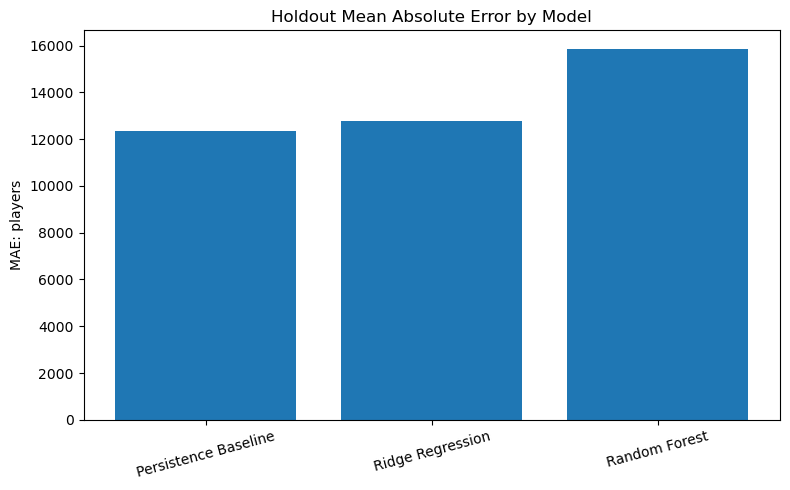

In [15]:
# 14. HOLDOUT MODEL EVALUATION
# ============================================================

ridge_pred = ridge_search.predict(
    X_test
)

rf_pred = rf_search.predict(
    X_test
)

ridge_scores = regression_metrics(
    y_test,
    ridge_pred,
)

rf_scores = regression_metrics(
    y_test,
    rf_pred,
)

comparison = pd.DataFrame(
    [
        {
            "Model": "Persistence Baseline",
            "CV_MAE": np.nan,
            **baseline_scores,
        },
        {
            "Model": "Ridge Regression",
            "CV_MAE": ridge_cv_mae,
            **ridge_scores,
        },
        {
            "Model": "Random Forest",
            "CV_MAE": rf_cv_mae,
            **rf_scores,
        },
    ]
)

comparison.to_csv(
    RESULTS_DIR / "model_comparison.csv",
    index=False,
)

print("\nModel comparison:")
print(
    comparison.sort_values("MAE")
)


# 14A. Model-comparison chart
plt.figure(figsize=(8, 5))
plt.bar(
    comparison["Model"],
    comparison["MAE"],
)
plt.title(
    "Holdout Mean Absolute Error by Model"
)
plt.ylabel("MAE: players")
plt.xticks(rotation=15)
save_figure(
    "04_model_mae_comparison.png"
)
plt.show()


Largest prediction errors:
   feature_month target_month  actual_next_month_players  \
1     2025-05-01   2025-06-01                   21027.89   
14    2026-06-01   2026-07-01                   49766.16   
3     2025-07-01   2025-08-01                   34574.73   
15    2026-07-01   2026-08-01                   24933.29   
8     2025-12-01   2026-01-01                   16160.82   

    predicted_next_month_players      residual  absolute_error  
1                   55227.562835 -34199.672835    34199.672835  
14                  82722.426286 -32956.266286    32956.266286  
3                   63449.148734 -28874.418734    28874.418734  
15                  47183.428270 -22250.138270    22250.138270  
8                   34612.276640 -18451.456640    18451.456640  


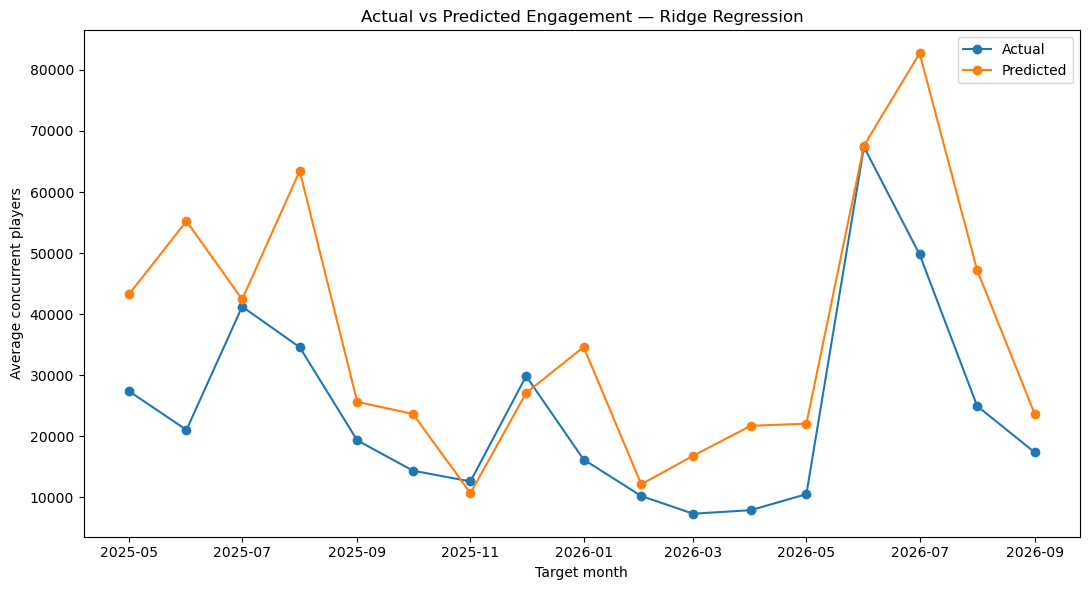

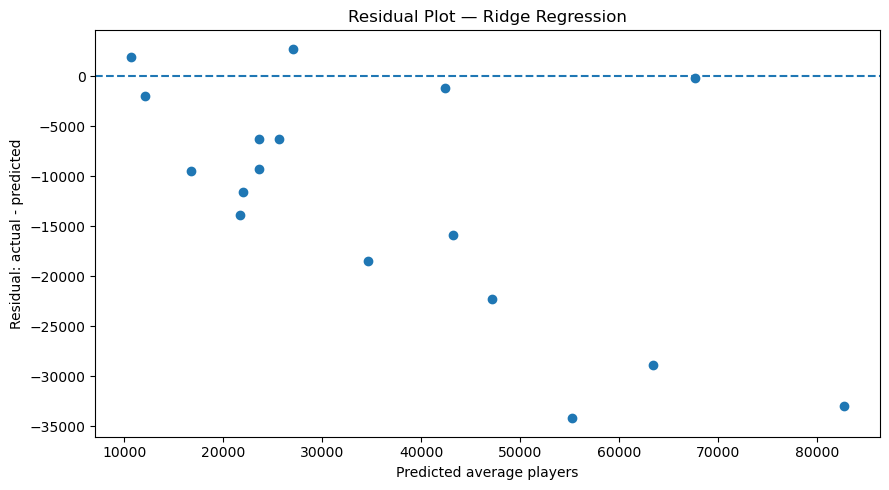

In [16]:
# 15. FINAL MODEL PREDICTIONS AND ERROR ANALYSIS

if final_name == "Random Forest":
    final_pred = rf_pred
else:
    final_pred = ridge_pred

predictions = pd.DataFrame(
    {
        "feature_month": test_df["month"].values,
        "target_month": test_df["target_month"].values,
        "actual_next_month_players": y_test.values,
        "predicted_next_month_players": final_pred,
    }
)

predictions["residual"] = (
    predictions[
        "actual_next_month_players"
    ]
    - predictions[
        "predicted_next_month_players"
    ]
)

predictions["absolute_error"] = (
    predictions["residual"].abs()
)

predictions.to_csv(
    RESULTS_DIR / "test_predictions.csv",
    index=False,
)

print("\nLargest prediction errors:")
print(
    predictions.nlargest(
        5,
        "absolute_error",
    )
)


# 15A. Actual vs predicted over time
plt.figure(figsize=(11, 6))
plt.plot(
    predictions["target_month"],
    predictions["actual_next_month_players"],
    marker="o",
    label="Actual",
)
plt.plot(
    predictions["target_month"],
    predictions["predicted_next_month_players"],
    marker="o",
    label="Predicted",
)
plt.title(
    f"Actual vs Predicted Engagement — {final_name}"
)
plt.xlabel("Target month")
plt.ylabel("Average concurrent players")
plt.legend()
save_figure(
    "05_actual_vs_predicted.png"
)
plt.show()


# 15B. Residuals
plt.figure(figsize=(9, 5))
plt.axhline(
    0,
    linestyle="--",
)
plt.scatter(
    predictions[
        "predicted_next_month_players"
    ],
    predictions["residual"],
)
plt.title(
    f"Residual Plot — {final_name}"
)
plt.xlabel("Predicted average players")
plt.ylabel("Residual: actual - predicted")
save_figure(
    "06_residual_plot.png"
)
plt.show()




## 8. Model Interpretation and Insights

Permutation importance measures how much predictive performance worsens when one feature is shuffled. Higher importance means the model depended more on that feature for accurate holdout predictions.

Because player-count history can dominate forecasting, the notebook also runs a secondary Random Forest excluding the two direct player-history features. This helps examine how community/content variables rank relative to one another.

**Important:** predictive importance does **not** prove causation.


Permutation feature importance:
                      feature  importance_mean  importance_std
6      announcement_count_log      3223.837969     1326.633848
3         positive_review_pct      2102.631920     1117.477303
8      months_since_expansion      1077.822115      581.101394
5   avg_review_playtime_hours       567.090480      296.314907
9                   month_sin       561.564806      535.601200
2            review_count_log       516.264838      465.928687
10                  month_cos        71.322333      435.920689
4        avg_review_sentiment         0.536286       37.577958
1        rolling3_avg_players       -40.193612       70.324771
7           expansion_release       -74.780556      134.072342
0         current_avg_players      -153.646193      152.507910


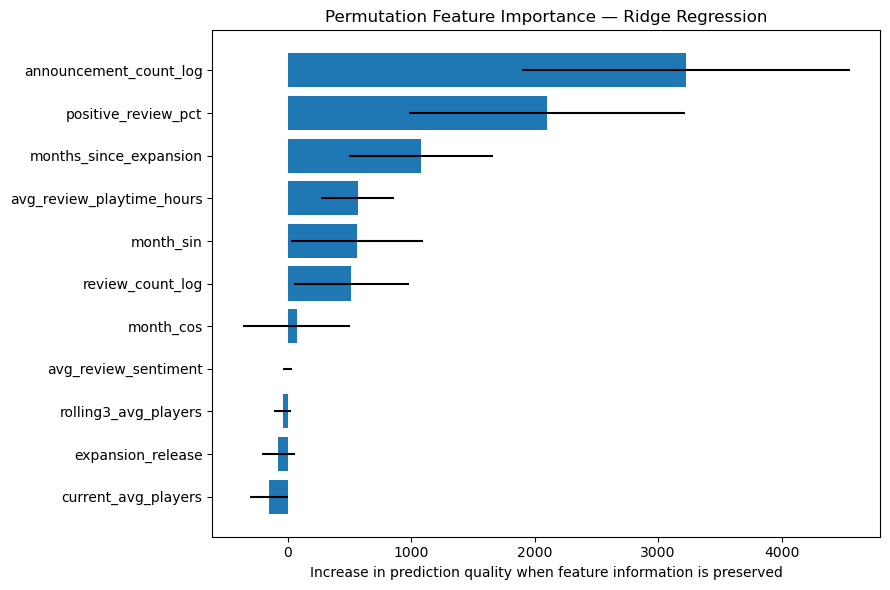

In [17]:
# 16. MODEL INTERPRETATION: PERMUTATION IMPORTANCE

# Permutation importance asks:
# "How much does prediction error get worse if this feature is shuffled?"
# This is more directly tied to predictive usefulness than raw tree
# impurity importance and works for either final model.

importance_result = permutation_importance(
    final_model,
    X_test,
    y_test,
    scoring="neg_mean_absolute_error",
    n_repeats=50,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame(
    {
        "feature": features,
        "importance_mean": (
            importance_result.importances_mean
        ),
        "importance_std": (
            importance_result.importances_std
        ),
    }
).sort_values(
    "importance_mean",
    ascending=False,
)

importance_df.to_csv(
    RESULTS_DIR / "feature_importance.csv",
    index=False,
)

print("\nPermutation feature importance:")
print(importance_df)


plt.figure(figsize=(9, 6))

plot_imp = importance_df.sort_values(
    "importance_mean",
    ascending=True,
)

plt.barh(
    plot_imp["feature"],
    plot_imp["importance_mean"],
    xerr=plot_imp["importance_std"],
)

plt.title(
    f"Permutation Feature Importance — {final_name}"
)
plt.xlabel(
    "Increase in prediction quality when feature information is preserved"
)

save_figure(
    "07_permutation_feature_importance.png"
)
plt.show()

In [18]:
# 17. SECONDARY INTERPRETATION:
#     BUSINESS/COMMUNITY FEATURES WITHOUT CURRENT PLAYER COUNT

# Because current player count is likely to dominate a forecasting model,
# this second analysis shows the ranking among more actionable/content/
# community variables. It is descriptive and should not replace the
# primary model evaluation.

non_lag_features = [
    f
    for f in features
    if f not in {
        "current_avg_players",
        "rolling3_avg_players",
    }
]

if len(non_lag_features) >= 2:
    secondary_rf = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="median"
                ),
            ),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=600,
                    max_depth=5,
                    min_samples_leaf=2,
                    random_state=RANDOM_STATE,
                    n_jobs=-1,
                ),
            ),
        ]
    )

    secondary_rf.fit(
        train_df[non_lag_features],
        y_train,
    )

    secondary_result = permutation_importance(
        secondary_rf,
        test_df[non_lag_features],
        y_test,
        scoring="neg_mean_absolute_error",
        n_repeats=50,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )

    secondary_importance = pd.DataFrame(
        {
            "feature": non_lag_features,
            "importance_mean": (
                secondary_result.importances_mean
            ),
            "importance_std": (
                secondary_result.importances_std
            ),
        }
    ).sort_values(
        "importance_mean",
        ascending=False,
    )

    secondary_importance.to_csv(
        RESULTS_DIR
        / "feature_importance_without_player_lags.csv",
        index=False,
    )

    print(
        "\nBusiness/community feature importance "
        "(excluding player-count history):"
    )
    print(secondary_importance)


Business/community feature importance (excluding player-count history):
                     feature  importance_mean  importance_std
0           review_count_log      2484.237859     1519.124976
6     months_since_expansion       186.155134      215.722791
7                  month_sin        37.017916      135.432945
3  avg_review_playtime_hours         3.945668       85.197014
8                  month_cos       -13.695665       28.711260
4     announcement_count_log       -65.871909      511.165002
5          expansion_release       -67.695999       77.171701
1        positive_review_pct      -116.013015       78.389668
2       avg_review_sentiment      -286.435930      329.206964


In [19]:
# 18. SAVE FINAL MODEL

joblib.dump(
    {
        "model_name": final_name,
        "model": final_model,
        "features": features,
        "target": target,
        "training_end": str(
            train_df["month"].max().date()
        ),
    },
    MODELS_DIR / "destiny2_engagement_model.joblib",
)

print(
    "\nSaved final model to:",
    MODELS_DIR / "destiny2_engagement_model.joblib",
)


Saved final model to: models\destiny2_engagement_model.joblib


In [20]:
# 19. AUTOMATIC PROJECT FACTS FOR THE PORTFOLIO WRITE-UP

project_facts = {
    "research_question": (
        "Which factors are most important in predicting "
        "next-month Destiny 2 Steam player engagement?"
    ),
    "task_type": "Regression",
    "unit_of_analysis": "One calendar month",
    "target": target,
    "rows_before_target_drop": int(len(df)),
    "model_rows": int(len(model_df)),
    "training_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "first_month": str(
        model_df["month"].min().date()
    ),
    "last_feature_month": str(
        model_df["month"].max().date()
    ),
    "features": features,
    "final_model_selected_by_cv": final_name,
    "baseline_test_metrics": baseline_scores,
    "ridge_test_metrics": ridge_scores,
    "random_forest_test_metrics": rf_scores,
    "top_predictive_features": (
        importance_df.head(5)["feature"].tolist()
    ),
    "missing_values_before_model_pipeline": {
        key: int(value)
        for key, value in (
            model_df[features]
            .isna()
            .sum()
            .items()
        )
    },
}

with open(
    RESULTS_DIR / "project_facts.json",
    "w",
    encoding="utf-8",
) as f:
    json.dump(
        project_facts,
        f,
        indent=2,
    )

print(
    "\nProject facts exported to:",
    RESULTS_DIR / "project_facts.json",
)


Project facts exported to: results\project_facts.json


## 9. Limitations, Ethics, and Reflection

Key limitations include:
- Steam-only engagement rather than all-platform engagement.
- Concurrent player count is a proxy, not revenue, monthly active users, retention, or total hours played.
- Monthly data produces a relatively small number of observations.
- English-language Steam reviewers are a self-selected population.
- Review sentiment comes from a capped sample of review text.
- Game releases, review activity, search interest, and player counts can respond to the same underlying events.
- Feature importance should not be interpreted as causal impact.
- Incorrect forecasts could lead to poor business decisions if treated as definitive.

The model is appropriate as an exploratory forecasting and analytical tool, but it should not be the sole basis for high-impact business decisions.

The Steam Charts only measures the concurrent players for Steam and does not include Playstation or Xbox data. Engagement proxy is not the same as active monthly users, hours played, retention, or revenue. The model uses a certain amount of observations to avoid overfitting the model. 

## References (APA)

Hamari, J., & Keronen, L. (2017). Why do people play games? A meta-analysis. *International Journal of Information Management, 37*(3), 125–141. https://doi.org/10.1016/j.ijinfomgt.2017.01.006

Kraemer, T., Weiger, W. H., & Heidenreich, S. (2025). Do all stars shine the same? Investigating the nonlinear effects of user and critic reviews on video game sales. *Journal of Business Research, 188*, 115034. https://doi.org/10.1016/j.jbusres.2024.115034

Zhu, F., & Zhang, X. (2010). Impact of online consumer reviews on sales: The moderating role of product and consumer characteristics. *Journal of Marketing, 74*(2), 133–148. https://doi.org/10.1509/jm.74.2.133

Valve Corporation. (n.d.). *IUserReviewsService*. Steamworks Documentation. https://partner.steamgames.com/doc/webapi/IUserReviewsService

Valve Corporation. (n.d.). *ISteamNews interface*. Steamworks Documentation. https://partner.steamgames.com/doc/webapi/ISteamNews

Steam Charts. (n.d.). *Destiny 2*. https://steamcharts.com/app/1085660

Bungie. (2024). *The Final Shape*. https://www.bungie.net/7/en/Destiny/theFinalShape

Bungie. (2025). *The Edge of Fate and Year of Prophecy reveal recap*. https://www.bungie.net/7/en/News/Article/year_of_prophecy_reveal_recap

## Code and AI Transparency


### AI usage disclosure

I used ChatGPT to help plan the project, debug code, and explain the ML concepts. I reviewed all the code, data sources, and responsible for all the output interpretations. 
